# Initiallize
Import libraries and functions provided by nix or conda environment

In [1]:
%matplotlib widget

In [2]:
# Initiallization
import tkinter as tk
from tkinter import filedialog
import glob
from natsort import natsorted
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.tools as tls
import plotly.graph_objs as go
import plotly.offline as pyo
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d

# Functions
Basic functions for pipeline

## File operation
Get File structure & read files

In [3]:
# Read and combine .csv files into a single dataframe
def combine_csv(folder_path, filtering_pattern):
    csv_file_paths = natsorted(glob.glob(os.path.join(folder_path, filtering_pattern)))

    matrices = []
    for file in csv_file_paths:
        mat = np.loadtxt ( file, delimiter=',', skiprows=3, usecols=(1,2,3) ) # Read and skip the first three rows of metadata, use 2nd, 3rd, 4th cloumn for the first point
        matrices.append(mat)
    if len(matrices) == 0:
        raise ValueError("No matching data found for the given pattern.")
    combined_matrix = np.vstack ( matrices ) # Combine the data into a combined matrix

    df = pd.DataFrame(combined_matrix, columns=['xPix', 'yPix', 'likelihood'])

    df['frameNum'] = df.index + 1
    
    return df

In [4]:
def read_timestamp(folder_path, filename):
    df_ts = pd.read_csv(os.path.join(folder_path, filename), sep='\t').drop(columns=['buffer'])
    df_ts.loc[0, 'sysClock'] = 0
    df_ts['timeSec'] = df_ts['sysClock'] / 1000
    df_ts = df_ts.drop(columns=['sysClock'])

    return df_ts

## Time and space converting
Convert timestamp/framenumber and pixels in video to real-world time and distance

In [5]:
# Converting pixel coordinate to real world coordinate

def space_convert(df, pixelX, pixelY, actualX, actualY):
    df['x'] = df['xPix'] / pixelX * actualX
    df['y'] = df['yPix'] / pixelY * actualY
    return df

In [6]:
# Directly suggest time by frame number, for hai's project

def framerate_convert(df, frame_rate):
    df['timeSec'] = df.index / frame_rate
    return df

In [7]:
def timestamp_convert(df, df_ts, camera_number):
    df_cam_ts = df_ts[df_ts['camNum'] == camera_number].reset_index(drop=True)

    merged_df = df_cam_ts.merge(
        df[['frameNum', 'xPix', 'yPix', 'likelihood']],
        on='frameNum',
        how='left'
    )
    
    # Replace NaNs in unmached lines with 0 for prediction
    merged_df['xPix'] = merged_df['xPix'].fillna(0)
    merged_df['yPix'] = merged_df['yPix'].fillna(0)
    merged_df['likelihood'] = merged_df['likelihood'].fillna(0)
    
    return merged_df

## Frame operation
Delete or add frames as needed

In [8]:
# For Hai's project with exactly same redundant frames
def drop_redundant_frames(df):
    cols = ['x', 'y']
    mask = (df[cols] == df[cols].shift(1)).all(axis=1)
    return df[~mask].reset_index(drop=True)

In [9]:
# For fixing Wirefree miniscope's messy dual camera 3D imaging
def insert_lost_frames(df):
    new_rows = []
    
    for i in range(len(df)-1):

        current_cam = df.iloc[i]['camNum']
        next_cam = df.iloc[i + 1]['camNum']

        current_row = df.iloc[i].copy()
        new_rows.append(current_row)

        if current_cam != next_cam:
            continue

        new_cam = 1 if current_cam == 0 else 0
                
        last_matching_row = None
        for j in range(i, -1, -1):
            if df.iloc[j]['camNum'] == new_cam:
                last_matching_row = df.iloc[j]
                break
                
        next_matching_row = None
        for j in range(i + 1, len(df)):
            if df.iloc[j]['camNum'] == new_cam:
                next_matching_row = df.iloc[j]
                break
                
        new_row = current_row.copy()
        new_row['camNum'] = new_cam
        new_row['frameNum'] = -1
                
        if last_matching_row is not None and next_matching_row is not None:
            # change the sysClock assign rule
            new_row['timeSec'] = (last_matching_row['timeSec'] + next_matching_row['timeSec']) / 2
        else:
            new_row['timeSec'] = current_row['timeSec']
                
        new_rows.append(new_row)
    
    new_df = pd.DataFrame(new_rows)
    
    new_df = new_df.reset_index(drop=True)
    
    return new_df

## Data filter
Remove the unneeded frames

In [10]:
# For removing the useless frames in Wirefree Miniscope project
def trim_frames(df, start_frame, duration_sec):
    start_row = df[df['frameNum'] == start_frame]
    start_time = start_row['timeSec'].iloc[0]
    end_time = start_time + duration_sec
    selected_df = df[(df['frameNum'] >= start_frame) & (df['timeSec'] <= end_time)]
    selected_df['timeSec'] = selected_df['timeSec'] - start_time
    return selected_df

In [11]:
def tag_likelihood(df, threshold):
    df.loc[df['likelihood'] >= threshold, 'toPredict'] = 0
    df.loc[df['likelihood'] < threshold, 'toPredict'] = 1
    return df

In [12]:
def tag_inserted(df, threshold):
    df.loc[df['frameNum'] == -1, 'toPredict'] = 1
    return df

In [13]:
def tag_overspeed(df, threshold):
    df.loc[df['speed'] >= threshold, 'toPredict'] = 1
    return df

## Predict algorithm
Use KNN to fill the frames that needs to be predicted

In [14]:
# Predict coordinates of tagged frames with KNN algorithm
def predict_coordinates(df, neighbors):

    train_data = df[df['toPredict'] == 0 ]
    predict_data = df[df['toPredict'] == 1 ]

    if predict_data.empty:
        raise ValueError("All likelihood are over the threshold, no data replaced")
    
    # Prepare the training data
    X_train = train_data[['timeSec']]
    y_train_x = train_data['x']
    y_train_y = train_data['y']

    # Predict X and Y
    model_x = KNeighborsRegressor(n_neighbors=neighbors)
    model_x.fit(X_train, y_train_x)
    predicted_x = model_x.predict(predict_data[['timeSec']])

    model_y = KNeighborsRegressor(n_neighbors=neighbors)
    model_y.fit(X_train, y_train_y)
    predicted_y = model_y.predict(predict_data[['timeSec']])

    # Replace X and Y coordinate in the original data
    df.loc[df['toPredict'] == 1, 'x'] = predicted_x
    df.loc[df['toPredict'] == 1, 'y'] = predicted_y
    
    return df

## Behavior analysis
Calculate attributes like speed 

In [15]:
def calc_speed_2D(df):
    dx = df['x'] - df['x'].shift(1)
    dy = df['y'] - df['y'].shift(1)
    dt = df['timeSec'] - df['timeSec'].shift(1)
    
    df['speed'] = np.sqrt(dx**2 + dy**2) / dt
    df.loc[df.index[0], 'speed'] = 0
    
    return df

In [16]:
def calc_direction(df):
    df['dx'] = df['x'].diff()
    df['dy'] = df['y'].diff()

    # Compute direction in degrees (0-360)
    df['direction'] = np.degrees(np.arctan2(df['dy'], df['dx']))
    df['direction'] = (df['direction'] + 360) % 360  # Ensure 0-360 range

    # Handle NaN for first row (no previous point)
    df['direction'] = df['direction'].fillna(0)  # Or interpolate/drop as needed
    
    return df

## Plot
Visualize the results
Try plotly lib to make them interactive

In [17]:
# Plot the 2D trajectory
def plot_trajectory(df, name):
    plt.figure(figsize=(15,15))
    plt.plot(df['x'], df['y'], linewidth = 1.0, linestyle='-', color='b')
    plt.xlabel('X axis')
    plt.ylabel('Y axis')
    plt.title(name)

    plt.savefig(name + '.png', transparent=False)
    plt.show()

In [18]:
# Plot the likelihood scatter heatmap
def plot_likelihood(df, name):
    plt.figure(figsize=(15,15))
    plt.scatter(df['x'], df['y'], c=df['likelihood'], cmap='jet', s=5)
    plt.colorbar(label='Likelihood')
    plt.xlabel('X axis')
    plt.ylabel('Y axis')
    plt.title(name)

    plt.savefig(name + '.png', transparent=False)
    plt.show()

In [19]:
def plot_speed_2D(df, name):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 25), gridspec_kw={'height_ratios': [4, 1]})

    # Speed-position heatmap
    sc = ax1.scatter(df['x'], df['y'], c=df['speed'], cmap='jet', s=5, vmin=0, vmax=10)
    cbar = plt.colorbar(sc, ax=ax1)
    cbar.set_label('speed')
    ax1.set_xlabel('X axis')
    ax1.set_ylabel('Y axis')
    ax1.set_title(name)

    # Speed-time line chart
    ax2.plot(df['timeSec'], df['speed'], color='blue')
    ax2.set_xlabel('Time (sec)')
    ax2.set_ylabel('Speed')
    ax2.set_title('Speed over time')

    plt.tight_layout()
    plt.savefig(name + '.png', transparent=False)
    plt.show()

In [20]:
def plot_trajectory_3d(df, name):
    # Create a 3D scatter plot (or line plot) using Plotly
    fig = go.Figure()

    # Add the trajectory as a 3D line plot
    fig.add_trace(go.Scatter3d(
        x=df['x'],
        y=df['y'],
        z=df['z'],
        mode='lines',
        line=dict(width=4, color='blue', dash='dash'),
        name='Trajectory'
    ))

    # Update the layout for better visualization
    fig.update_layout(
        title="Interactive 3D Trajectory Plot",
        scene=dict(
            xaxis_title="X axis",
            yaxis_title="Y axis",
            zaxis_title="Z axis",
            aspectmode='cube'  # Ensure axes are scaled proportionally
        ),
        showlegend=True
    )

    # Export to HTML
    fig.write_html(name + '.html', auto_open=True) # Switch for instant view

    # Show it
    fig.show

In [21]:
def plot_2d_trajectory_with_direction(df, name):
    import matplotlib.cm as cm
    import plotly.graph_objects as go

    # Normalize direction to 0-1 for colormap
    dir_norm = df['direction'] / 360.0

    # Get colors from matplotlib's rainbow colormap
    cmap = cm.get_cmap('rainbow')
    colors_rgba = cmap(dir_norm)

    # Normalize speed
    speed_norm = df['speed'] / df['speed'].max() if df['speed'].max() > 0 else df['speed']

    # Apply gamma correction using speed_norm as gamma
    colors_gamma = []
    for i, color in enumerate(colors_rgba):
        gamma = speed_norm.iloc[i] if speed_norm.iloc[i] > 0 else 1.0  # Avoid gamma=0
        r, g, b, a = color
        r = r ** gamma
        g = g ** gamma
        b = b ** gamma
        colors_gamma.append((r, g, b))

    # Generate 2D Plot with Plotly
    fig = go.Figure()

    # Add colored line segments
    for i in range(len(df) - 1):
        fig.add_trace(go.Scatter(
            x=df['X'].iloc[i:i+2],
            y=df['Y'].iloc[i:i+2],
            mode='lines',
            line=dict(
                color=f'rgb({int(colors_gamma[i][0]*255)}, {int(colors_gamma[i][1]*255)}, {int(colors_gamma[i][2]*255)})',
                width=5
            ),
            showlegend=False
        ))

    # Add markers
    fig.add_trace(go.Scatter(
        x=df['X'],
        y=df['Y'],
        mode='markers',
        marker=dict(
            size=5,
            color=[f'rgb({int(r*255)}, {int(g*255)}, {int(b*255)})' for r, g, b in colors_gamma],
            symbol='circle'
        ),
        showlegend=False
    ))

    # Customize Layout
    fig.update_layout(
        title=name,
        xaxis_title='X',
        yaxis_title='Y',
        showlegend=False
    )

    # Export to HTML
    fig.write_html(name + '.html', auto_open=True)  # Switch for instant view
    fig.show()

In [22]:
def plot_3d_trajectory_with_direction(df, name):
# Normalize direction to 0-1 for colormap
    dir_norm = df['direction'] / 360.0

    # Get colors from matplotlib's rainbow colormap
    cmap = cm.get_cmap('rainbow')
    colors_rgba = cmap(dir_norm)

    # Normalize speed
    speed_norm = df['speed'] / df['speed'].max() if df['speed'].max() > 0 else df['speed']

    # Apply gamma correction using speed_norm as gamma
    colors_gamma = []
    for i, color in enumerate(colors_rgba):
        gamma = speed_norm.iloc[i] if speed_norm.iloc[i] > 0 else 1.0  # Avoid gamma=0
        r, g, b, a = color
        r = r ** gamma
        g = g ** gamma
        b = b ** gamma
        colors_gamma.append(rgb2hex((r, g, b)))

    # Generate 3D plot with Plotly
    fig = go.Figure(data=[go.Scatter3d(
        x=df['x'],
        y=df['y'],
        z=df['z'],
        mode='lines+markers',  # Lines for trajectory, markers for points
        line=dict(
            color=colors_gamma,  # Use gamma-adjusted colors for the line
            width=5,
            colorscale=None  # Custom colors
        ),
        marker=dict(
            size=5,
            color=colors_gamma,  # Colors based on direction with gamma
            symbol='circle'
        )
    )])

    # Customize layout
    fig.update_layout(
        title=name,
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        showlegend=True
    )

    # Export to HTML
    fig.write_html(name + '.html', auto_open=True) # Switch for instant view

    fig.show()

# Pipeline
Use functions to process data

## Get&goto the file path then read & combine all the behavioral data by filter

In [23]:
# Project data folder
os.chdir("/home/Sol/Documents/Ann")

In [24]:
# Get the folder path

root = tk.Tk()
root.withdraw()

folder_path_session = filedialog.askdirectory(
    title='Choose the folder containing all the data for this session'
)

os.chdir(folder_path_session) # Change the working directory to the data folder

folder_path_h = folder_path_session

# folder_path_h = filedialog.askdirectory(
#     title='Choose the folder containing your .csv horizontal behavioral data files'
# )

# folder_path_v = filedialog.askdirectory(
#     title='Choose the folder containing your .csv vertical behavioral data files'
# )

In [25]:
# Set some metadata
start_frame = 0

In [26]:
df_h = combine_csv(folder_path_h, "*.csv") # For 2D

In [27]:
df_h

,xPix,yPix,likelihood,frameNum
0,8.117981,290.10516,0.009573,1
1,8.143627,290.10730,0.007552,2
2,8.159784,290.13736,0.007303,3
3,8.159784,290.18567,0.007968,4
4,8.159784,290.32320,0.009106,5
...,...,...,...,...
4810,552.077150,102.78717,0.702785,4811
4811,552.077150,102.78717,0.654797,4812
4812,557.699500,106.48627,0.806039,4813
4813,557.699500,106.48627,0.687066,4814


## Timespace convert

In [28]:
# df = framerate_convert(df, 30) # For Hai's project
# df = timestamp_convert(df, df_ts, 0) # For 2D Walkway
# df_h = timestamp_convert(df_h, df_ts, 0) # For 3D Horizontal

In [29]:
df_h = space_convert(df_h, 372, 202, 64.36, 34.95) # For 2D Walkway

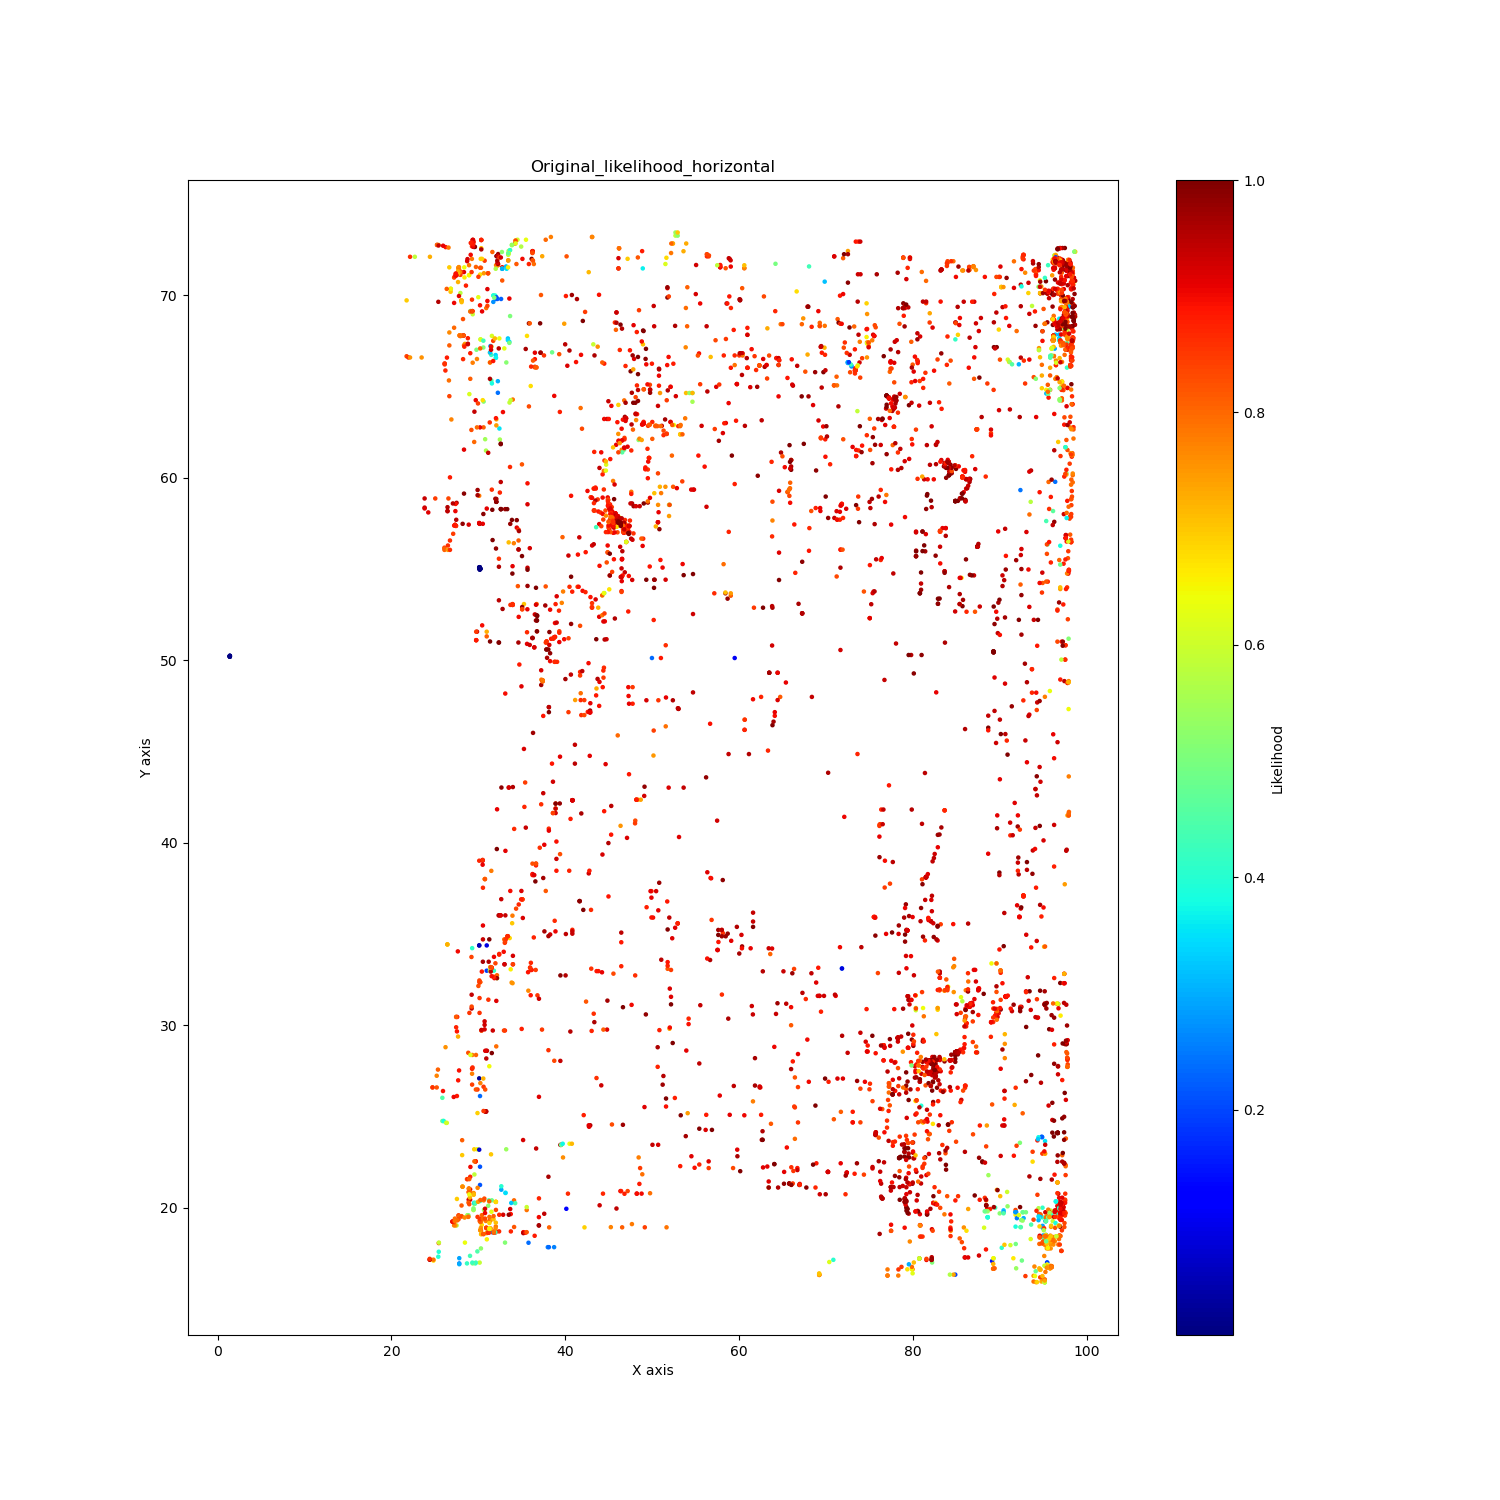

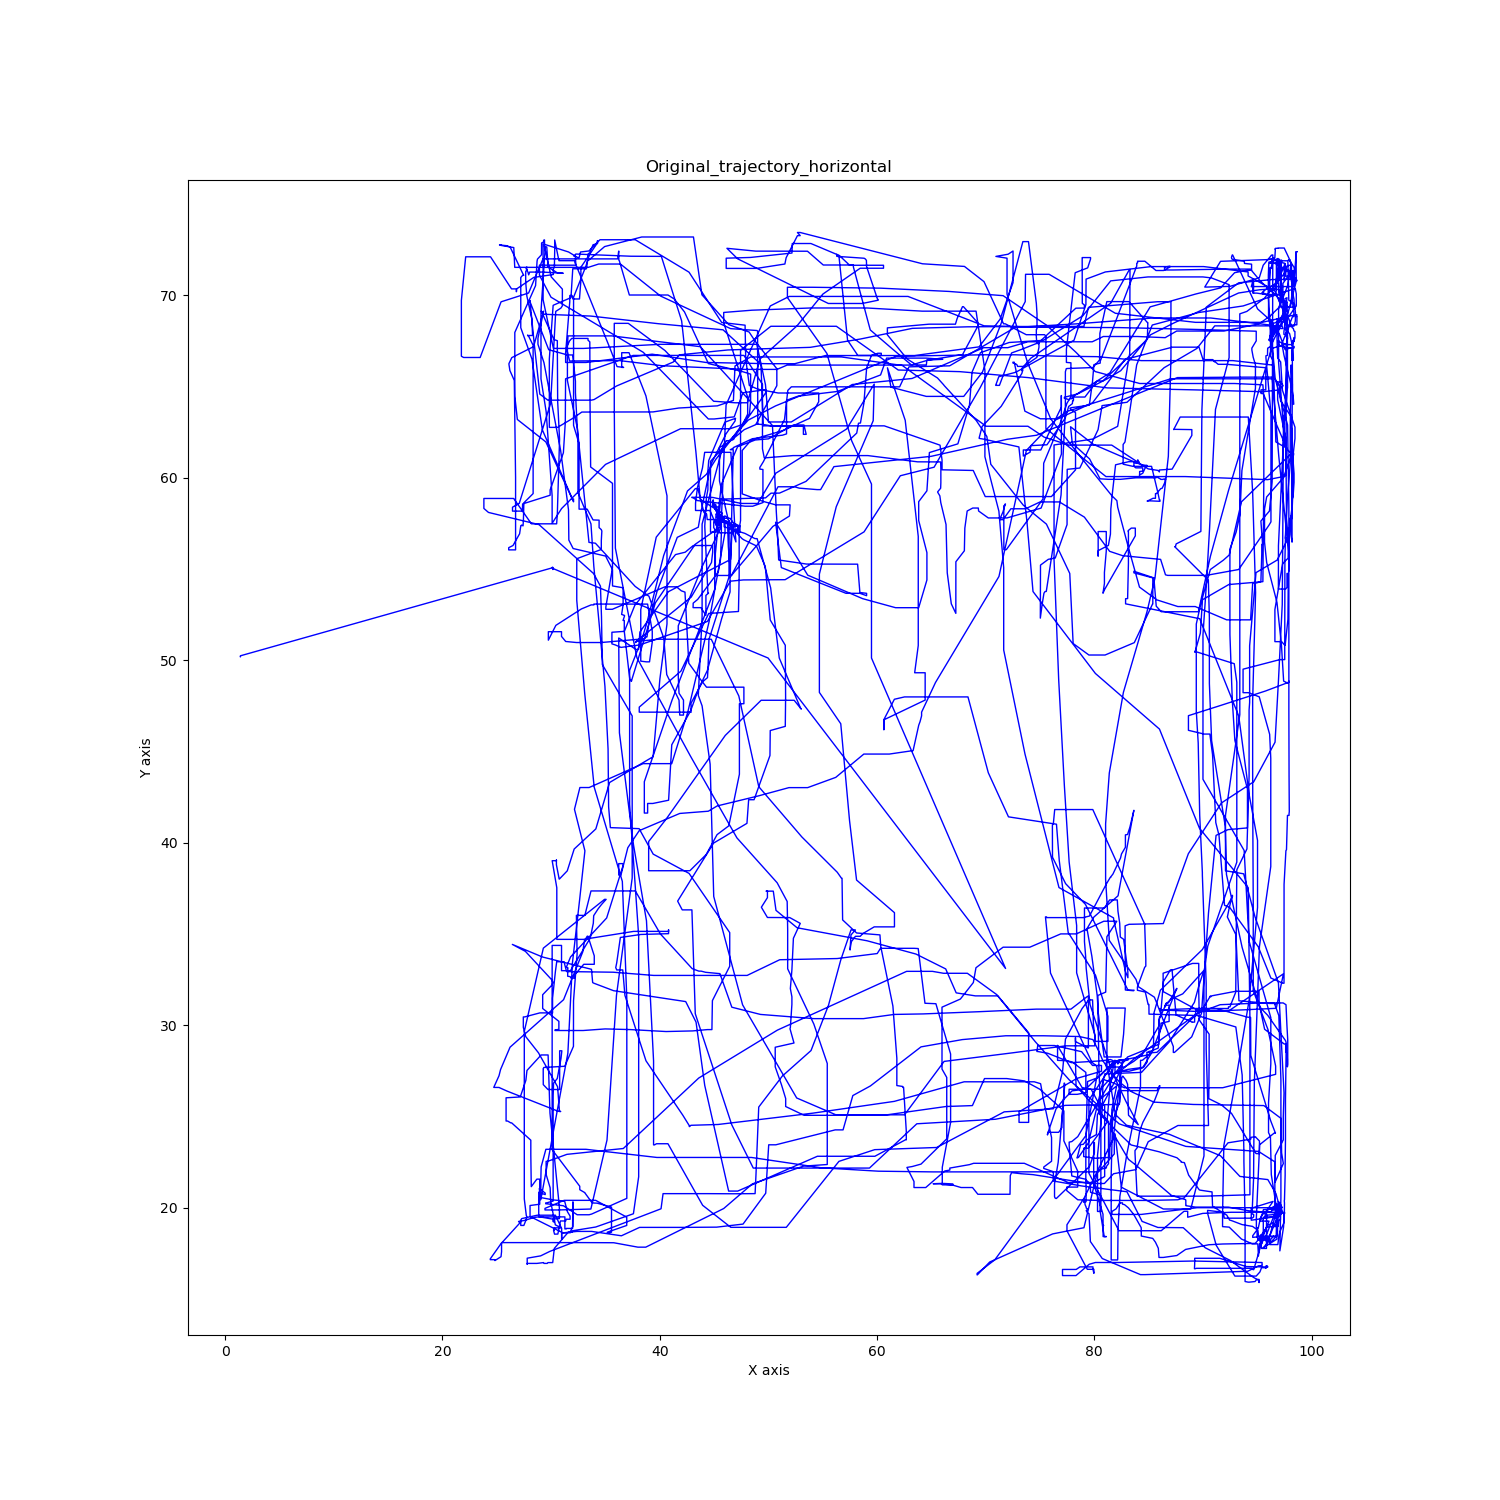

In [30]:
# Plot the likelihood scatter heatmap, trajectory and speed
plot_likelihood(df_h, 'Original_likelihood_horizontal')
plot_trajectory(df_h, 'Original_trajectory_horizontal')

## Filtering & predict the coordinates with low likelihood

In [37]:
df_h['timeSec'] = df_h.index

In [38]:
df_h = tag_likelihood(df_h, 0.6)
df_h = predict_coordinates(df_h, 10)

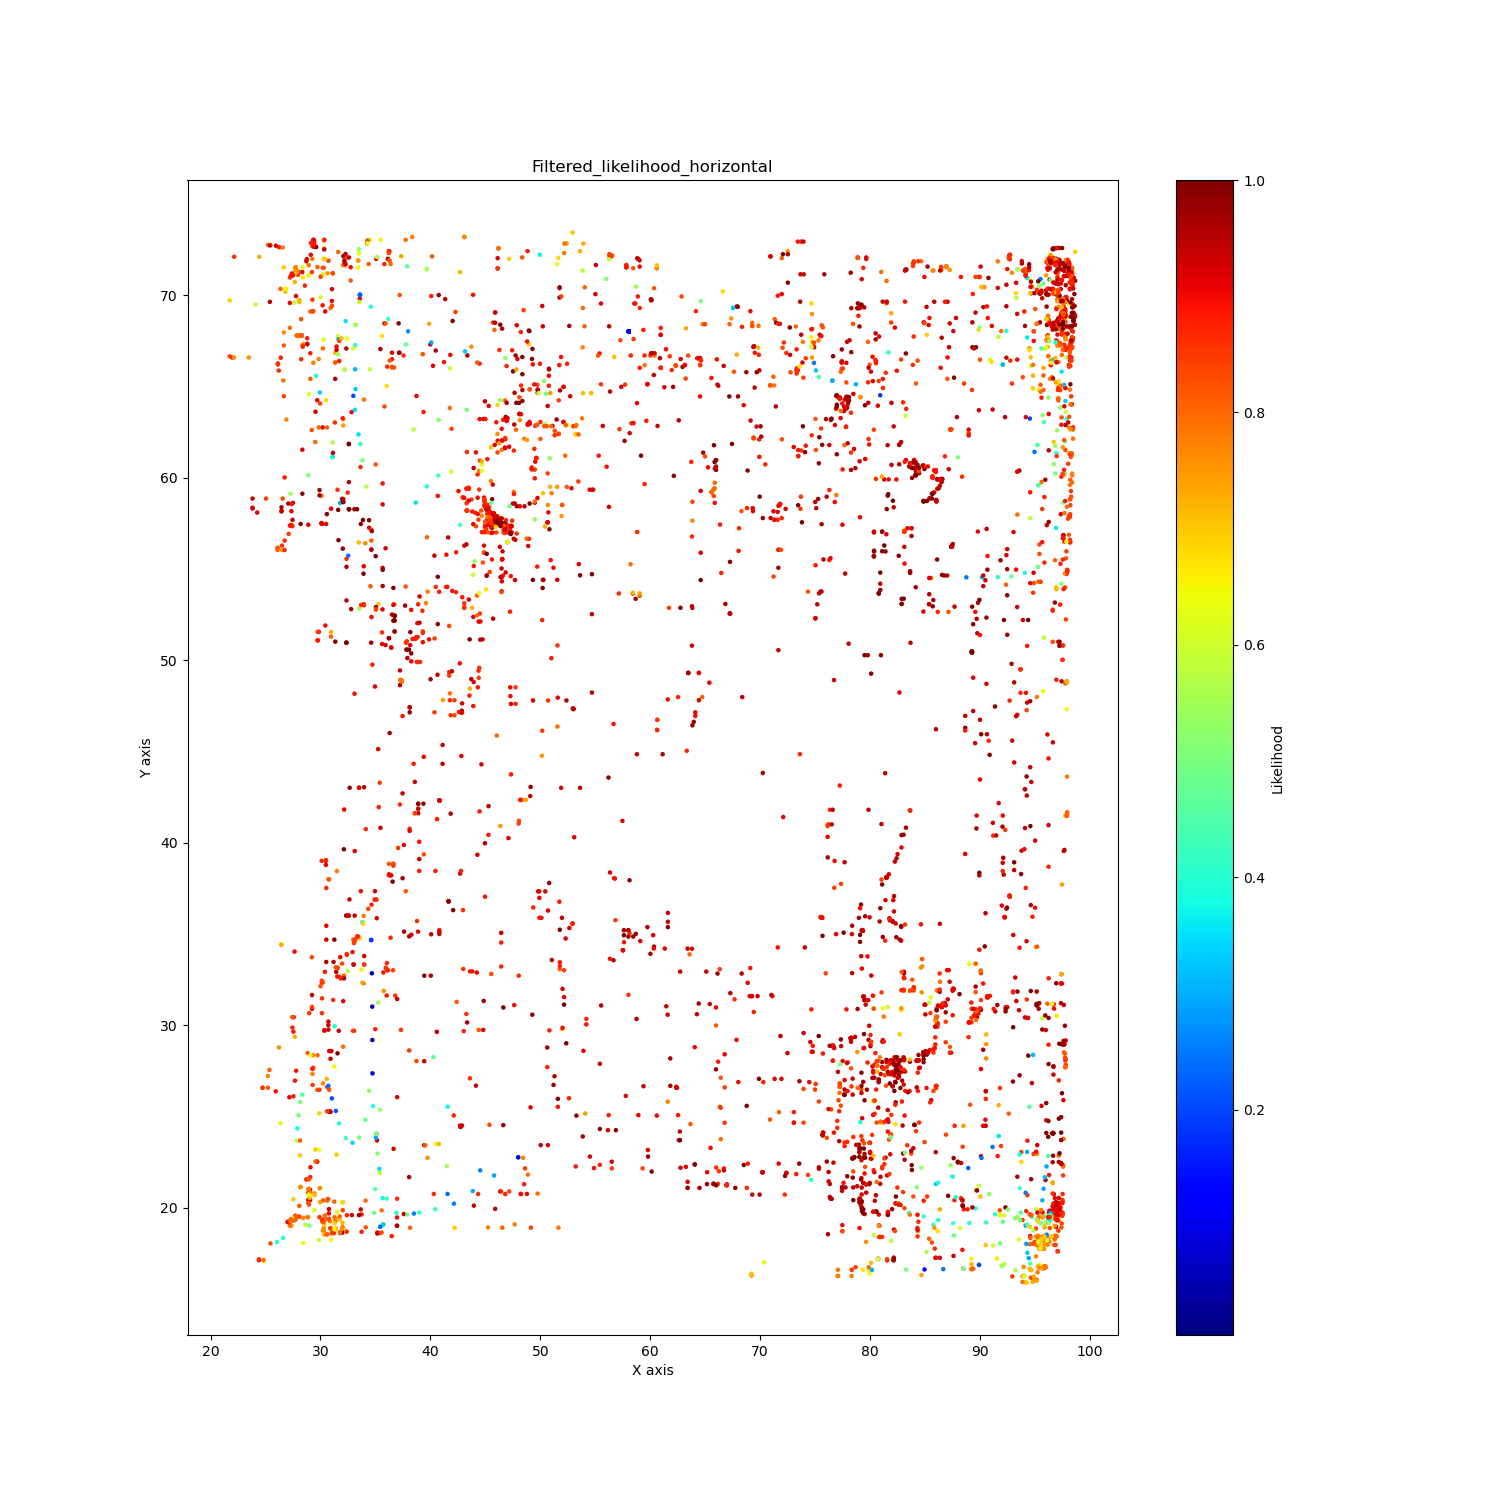

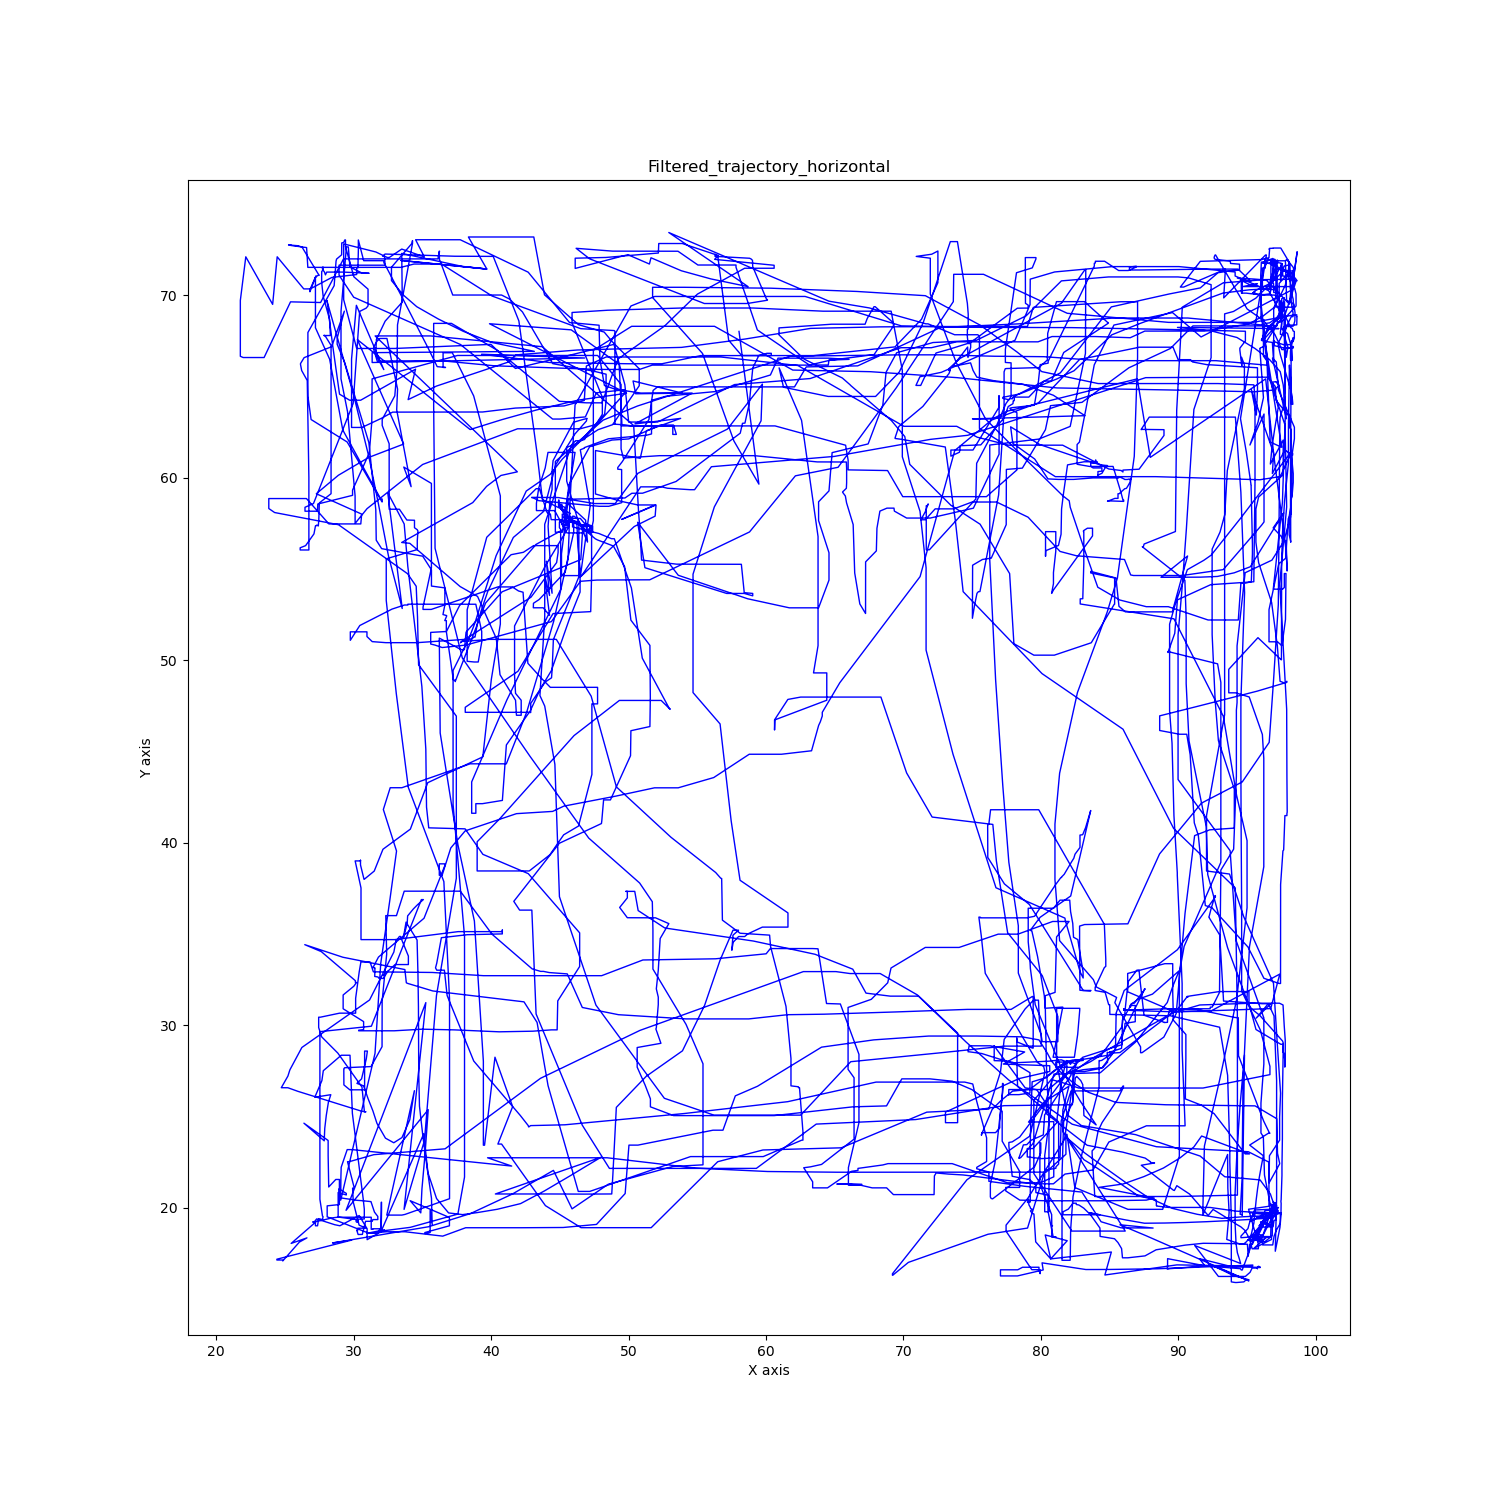

In [39]:
plot_likelihood(df_h, 'Filtered_likelihood_horizontal')
plot_trajectory(df_h, 'Filtered_trajectory_horizontal')

## Behavioral analysis and save

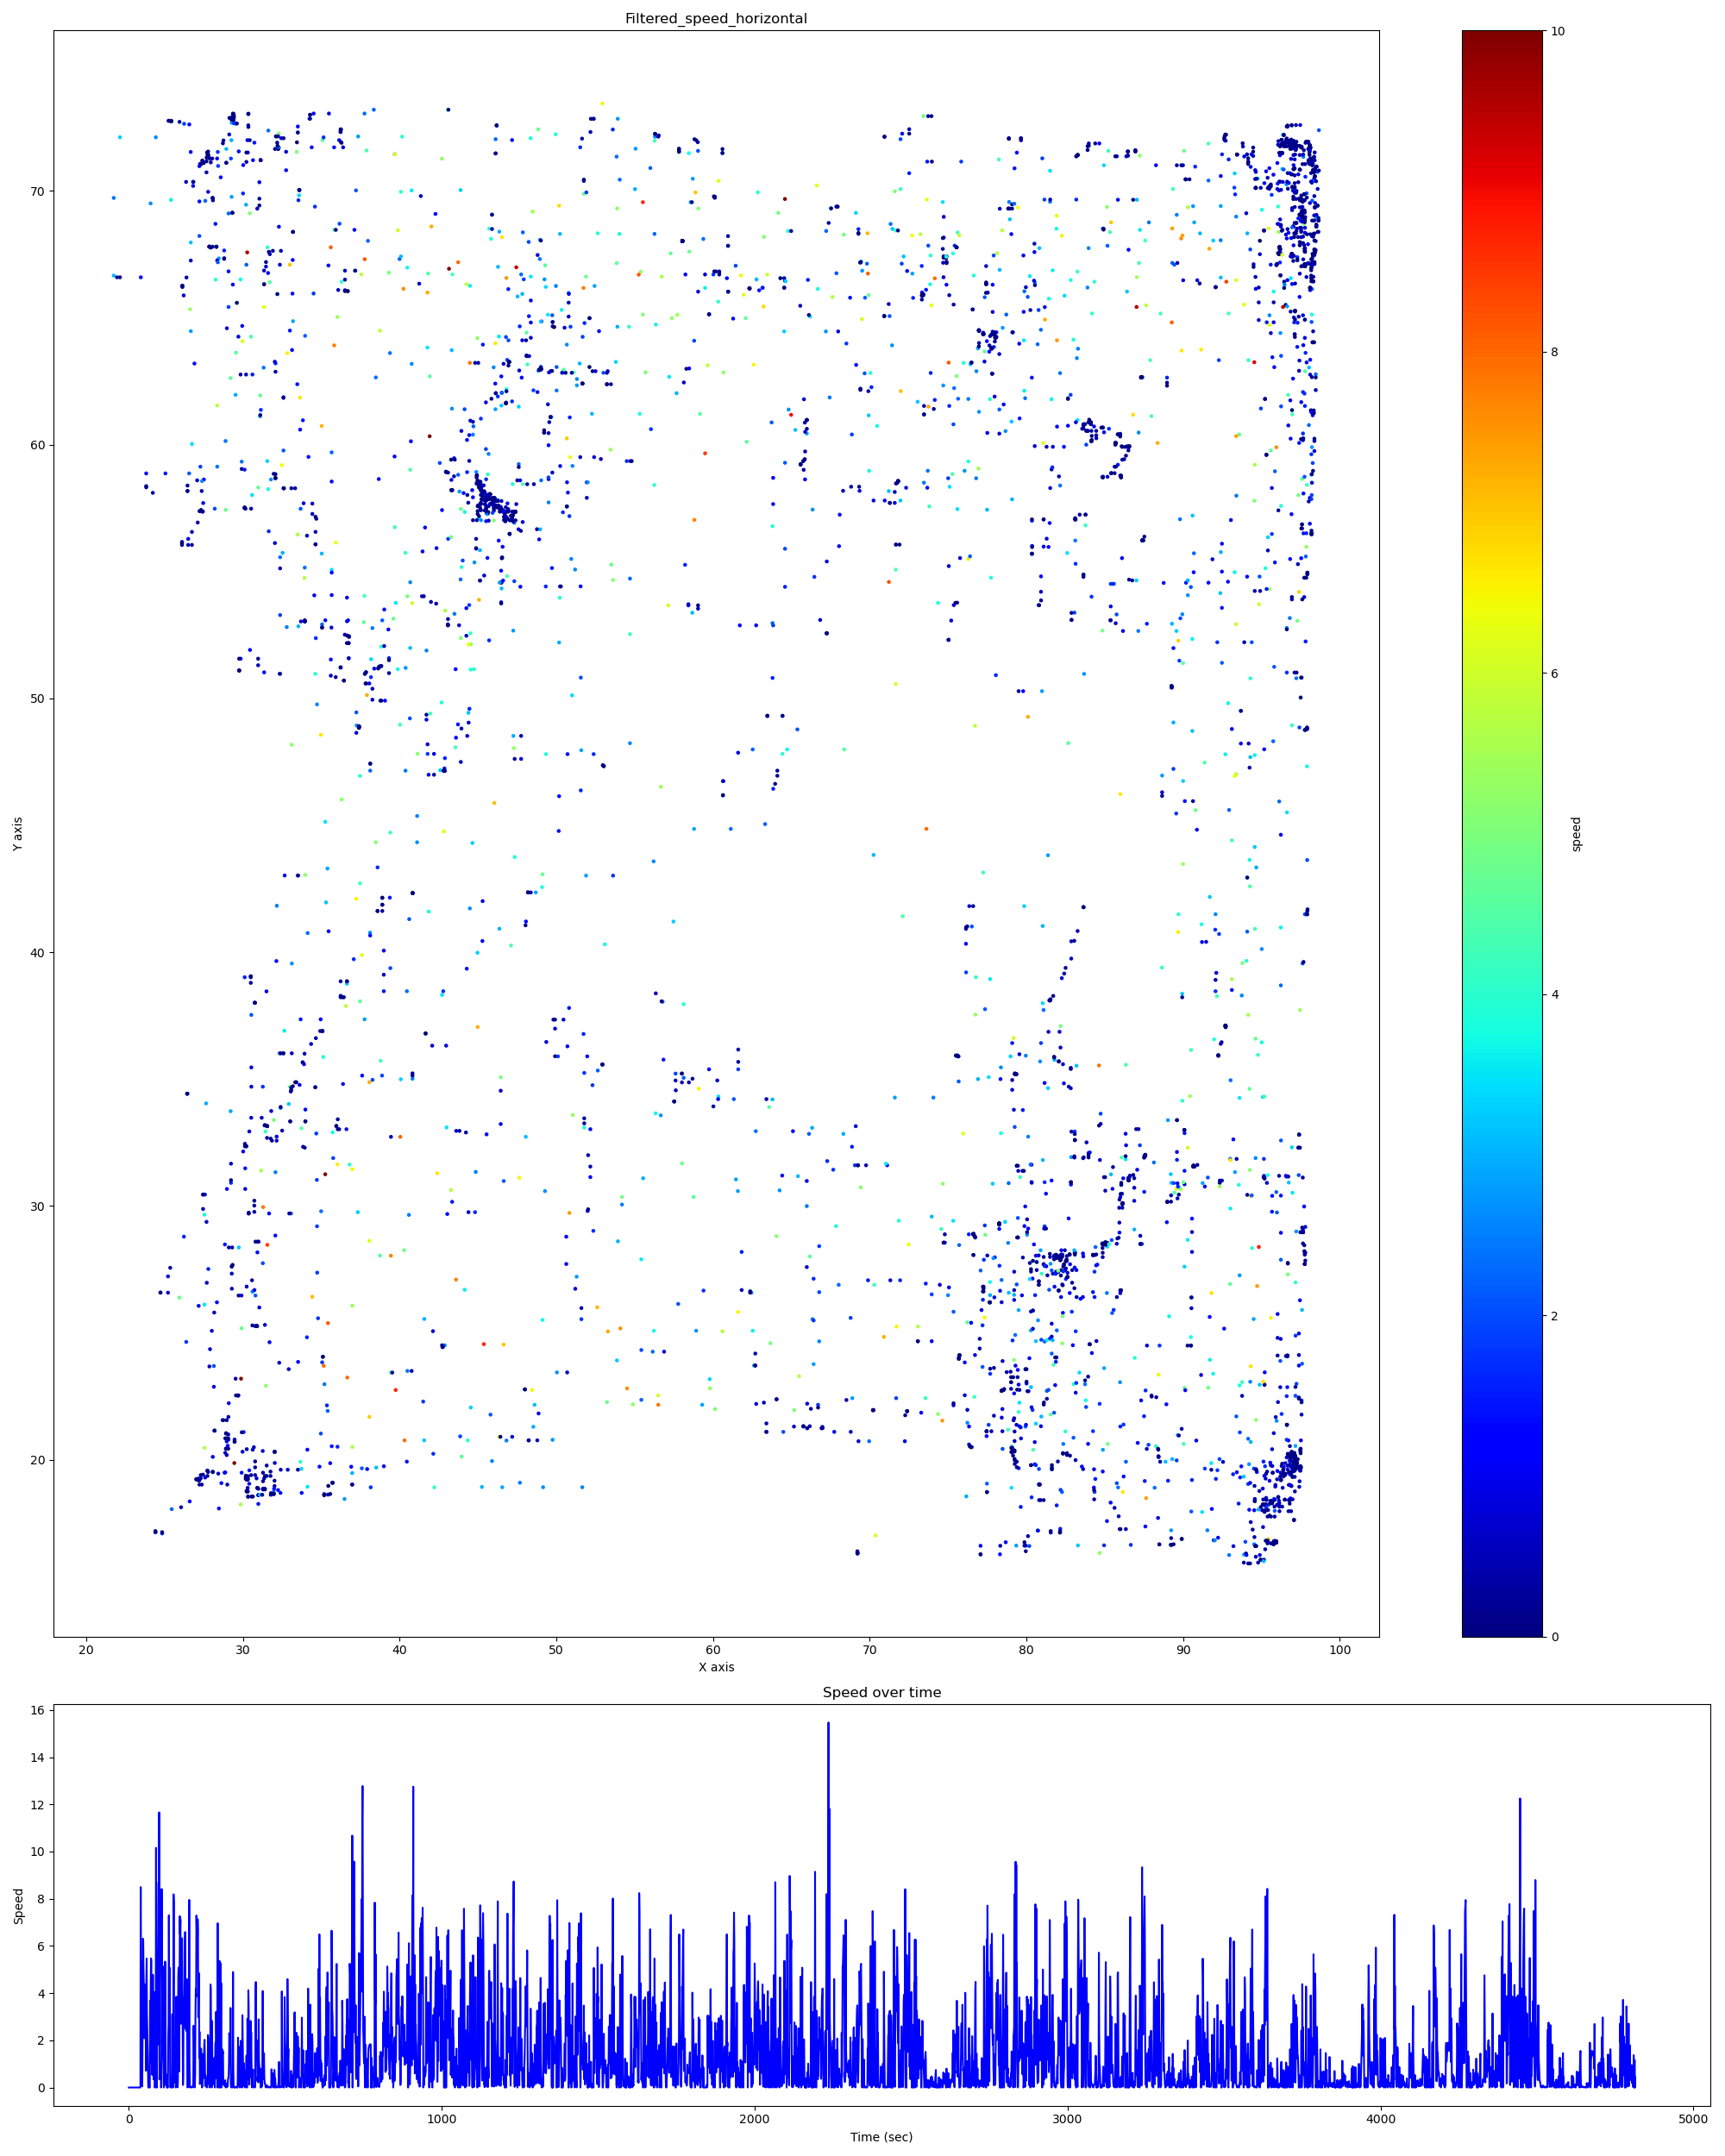

In [40]:
calc_speed_2D(df_h)
# df['isRunning'] = df['speed'] >= 1 # For Hai's project
plot_speed_2D(df_h, 'Filtered_speed_horizontal')

In [41]:
# df = tag_overspeed(df, 100)
# df = predict_coordinates(df, 10)

In [42]:
# calc_speed_2D(df)
# df['isRunning'] = df['speed'] >= 1 # For Hai's project
# plot_speed_2D(df, 'Filtered_speed')
# plot_trajectory(df, 'Filtered_speed_trajectory')

In [43]:
# df_h.to_csv ('Solysis_results/behavior_horizontal.csv', index = True )
df_h

,xPix,yPix,likelihood,frameNum,x,y,toPredict,timesec,timeSec,speed
0,8.117981,290.10516,0.009573,1,58.040134,68.028528,1.0,0,0,0.000000
1,8.143627,290.10730,0.007552,2,58.040134,68.028528,1.0,1,1,0.000000
2,8.159784,290.13736,0.007303,3,58.040134,68.028528,1.0,2,2,0.000000
3,8.159784,290.18567,0.007968,4,58.040134,68.028528,1.0,3,3,0.000000
4,8.159784,290.32320,0.009106,5,58.040134,68.028528,1.0,4,4,0.000000
...,...,...,...,...,...,...,...,...,...,...
4810,552.077150,102.78717,0.702785,4811,95.515283,17.784216,0.0,4810,4810,0.000000
4811,552.077150,102.78717,0.654797,4812,95.515283,17.784216,0.0,4811,4811,0.000000
4812,557.699500,106.48627,0.806039,4813,96.488010,18.424233,0.0,4812,4812,1.164397
4813,557.699500,106.48627,0.687066,4814,96.488010,18.424233,0.0,4813,4813,0.000000


## Combine them as 3D trajectory

In [44]:
df_h['z'] = 0

In [45]:
df_h

,xPix,yPix,likelihood,frameNum,x,y,toPredict,timesec,timeSec,speed,z
0,8.117981,290.10516,0.009573,1,58.040134,68.028528,1.0,0,0,0.000000,0
1,8.143627,290.10730,0.007552,2,58.040134,68.028528,1.0,1,1,0.000000,0
2,8.159784,290.13736,0.007303,3,58.040134,68.028528,1.0,2,2,0.000000,0
3,8.159784,290.18567,0.007968,4,58.040134,68.028528,1.0,3,3,0.000000,0
4,8.159784,290.32320,0.009106,5,58.040134,68.028528,1.0,4,4,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
4810,552.077150,102.78717,0.702785,4811,95.515283,17.784216,0.0,4810,4810,0.000000,0
4811,552.077150,102.78717,0.654797,4812,95.515283,17.784216,0.0,4811,4811,0.000000,0
4812,557.699500,106.48627,0.806039,4813,96.488010,18.424233,0.0,4812,4812,1.164397,0
4813,557.699500,106.48627,0.687066,4814,96.488010,18.424233,0.0,4813,4813,0.000000,0


In [46]:
df_trimmed = trim_frames(df_h, start_frame, 899.910)
df_3D = df_trimmed.drop(columns=['camNum','frameNum','xPix','yPix','likelihood','toPredict','speed'])
df_3D

IndexError: single positional indexer is out-of-bounds

In [ ]:
plot_trajectory_3d(df_3D, '3D_trajectory')

## Trim the video, then resampling to 30 frames

In [ ]:
# Resample in 30fps
def resample_trajectory(df, fps=30):

    if not isinstance(df, pd.DataFrame):
        raise TypeError("Has to be pandas DataFrame")

    # Generate isometric timestamps
    t_start = df['timeSec'].min()
    t_end = df['timeSec'].max()
    
    frame_interval = 1.0 / fps

    new_timestamps = np.arange(t_start, t_end, frame_interval)
    
    # Prepare the DataFrame to output
    resampled_df = pd.DataFrame({'timeSec': new_timestamps})
    
    # Do linear interpolation for each other columns
    coord_columns = [col for col in df.columns if col != 'timeSec']
    
    for col in coord_columns:
        interpolator = interp1d(df['timeSec'], df[col], kind='linear', fill_value='extrapolate')
        resampled_df[col] = interpolator(new_timestamps)
    
    return resampled_df

In [ ]:
df_fine = resample_trajectory(df_3D)

In [ ]:
df_fine

In [ ]:
plot_trajectory_3d(df_fine, '3D_trajectory')

In [ ]:
plot_2d_trajectory_with_direction(df_fine, '2D_trajectory')

In [ ]:
df_fine.to_csv ('final_behavior.csv', index = True )